In [2]:
# --- Standard library ---
import sys
import os
from os.path import join
import time

# --- Third-party scientific stack ---
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- Machine learning / statistics ---
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE, SpectralEmbedding
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
from sklearn.metrics import pairwise
from sklearn.metrics.pairwise import pairwise_kernels
from sklearn.cluster import AffinityPropagation

# --- SciPy ---
from scipy.linalg import LinAlgError, qr, svd
from scipy.sparse import csgraph

# --- Utilities ---
from tqdm import tqdm
import joblib
from joblib import parallel_backend
import numexpr as ne

# --- Local / custom modules ---
import fpsample



# Self-written libraries
sys.path.append(join(os.getcwd(), "library"))
import SPC

# Loading

In [3]:
adu_per_photon = 11250 / 2
layer_absorption = 0.58785  # SiN membrane + multilayer
reference_transmission_contribution = 0.01351  # of total transmitted intensity


def intensity_to_incident_number_photons(
        intensity, adu_per_photon, layer_absorption, reference_transmission_contribution
    ):
        # Calc number photons transmitted through sample
        nr_transmitted_photons = intensity / adu_per_photon

        # Correct for transmission through magnetic layer
        nr_incident_photons_object = (
            (1 - reference_transmission_contribution)
            * nr_transmitted_photons
            / layer_absorption
        )

        return nr_incident_photons_object, nr_transmitted_photons

In [46]:

# Processing the file CCI_Reference_filtered_Holo_ImId_161_RefId_[159, 158]_frame_bins_0001_section_1_stacked.h5 is time‑consuming.

#fname=r'D:\used\CCI_Reference_filtered_Holo_ImId_152_RefId_[154, 153]_frame_bins_0001_section_1_stacked\CCI_Reference_filtered_Holo_ImId_152_RefId_[154, 153]_frame_bins_0001_section_1_stacked.h5'
#fname=r'D:\used\CCI_Reference_filtered_Holo_ImId_152_RefId_[154, 153]_frame_bins_0001_section_1_stacked\CCI_Reference_filtered_Holo_ImId_125_RefId_[123, 122]_frame_bins_0001_section_1_stacked.h5'
fname=r'D:\used\CCI_Reference_filtered_Holo_ImId_152_RefId_[154, 153]_frame_bins_0001_section_1_stacked\CCI_Reference_filtered_Holo_ImId_161_RefId_[159, 158]_frame_bins_0001_section_1_stacked.h5'
# Opening of data files
with xr.open_dataset(fname) as data:
    print(data.keys())
    print(data["assignment_diff_level2"].values.shape)
    print(data["correlation_diff"].values.shape)
    corr_map=data["correlation_diff"].values
    assignment=data["assignment_diff_level2"].values
    assignment=np.reshape(assignment,assignment.shape[0] * assignment.shape[1])
    idx = ~np.isnan(corr_map[0])
    corr_map = corr_map[idx, :]
    fragment_ = corr_map[:, idx]
    #fragment=corr_map[np.ix_(idx, idx)]
    assignment = assignment[idx]
    print(fragment_.shape)
    print(assignment.shape)
    # Convert intensity
    intensity = data["intensity_frames_mask_pixel_corrected"].values.copy()
    intensity = np.reshape(
    intensity, intensity.shape[0] *intensity.shape[1]
    )
    intensity = intensity_to_incident_number_photons(
        intensity,
        adu_per_photon,
        layer_absorption,
        reference_transmission_contribution,
        )[0]
    intensity = intensity[idx]

KeysView(<xarray.Dataset> Size: 6GB
Dimensions:                                (time: 101, scan_id: 250, y: 680,
                                            x: 680, yr: 181, xr: 181,
                                            frame_seq_k1: 25250,
                                            frame_seq_k2: 25250)
Coordinates:
  * time                                   (time) float64 808B 0.0 0.04 ... 4.0
  * scan_id                                (scan_id) <U85 85kB '/das/home/ext...
Dimensions without coordinates: y, x, yr, xr, frame_seq_k1, frame_seq_k2
Data variables: (12/24)
    im_mean                                (scan_id, y, x) float32 462MB ...
    topo_c                                 (y, x) float32 2MB ...
    helicity                               (scan_id) int64 2kB ...
    mask_pixel                             (y, x) float64 4MB ...
    mask_pixel_smooth                      (y, x) float64 4MB ...
    drift_y                                (scan_id, time) float64 202kB .

In [47]:
# Time index
# NOTE:
# This method is not training a model yet, so it cannot handle large-scale data.
# For stability and reasonable memory usage, it’s recommended not to exceed ~5000 frames.

idx_1 = np.arange(3000, 8000)
idx = idx_1
fragment = fragment_[idx, :][:, idx]


In [48]:
def relabel(my_labels_filter):
    """
    NOTE:
    This function collapses each connected label group to its median index,
    then reassigns labels to consecutive integers starting from 0.
    """

    my_labels_filter = np.array(my_labels_filter)
    unique_items = np.unique(my_labels_filter[~np.isnan(my_labels_filter)])[:]

    # Replace each label group with the median index of that group
    for i in unique_items:
        indices = np.where(my_labels_filter == i)
        Median_indice = indices[0][len(indices[0]) // 2]
        my_labels_filter[indices[0]] = Median_indice

    # Sort unique median indices and map them to 0, 1, 2, ...
    unique_items = np.sort(np.unique(my_labels_filter)[:])

    for i in range(len(unique_items)):
        my_labels_filter[my_labels_filter == unique_items[i]] = i

    labels = np.array(my_labels_filter)
    return labels


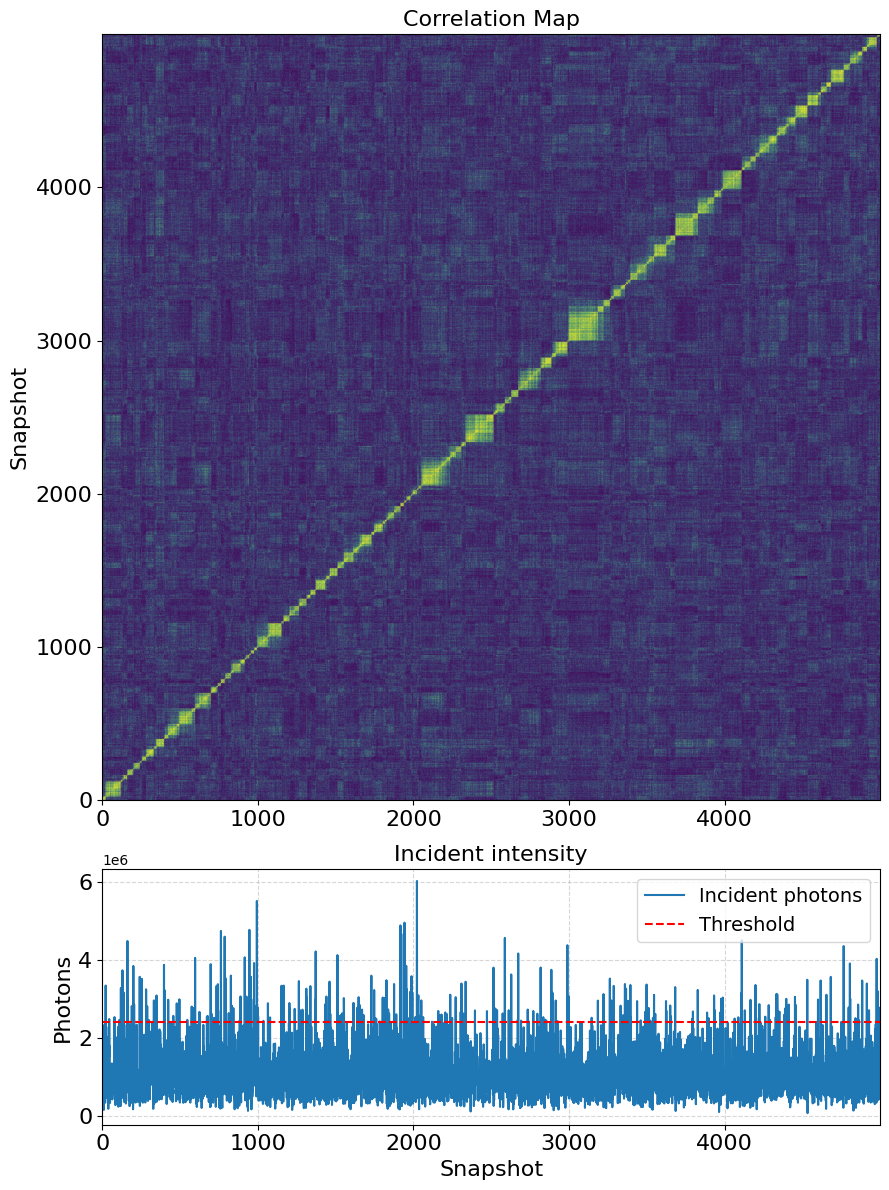

In [49]:
# Compute display range using robust percentiles
# NOTE:
# The correlation matrix may contain a long tail of small or noisy values.
# Using the 1st–99th percentile range suppresses outliers and improves visual contrast.
vmi, vma = np.percentile(fragment[fragment >= 1e-5], [1, 99])

fig = plt.figure(figsize=(9, 12))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])

# Upper plot: heatmap
ax0 = fig.add_subplot(gs[0])
im = ax0.imshow(fragment, vmin=vmi, vmax=vma, aspect='auto')
ax0.set_ylabel("Snapshot", fontsize=16)
ax0.set_title("Correlation Map", fontsize=16)

# Lower plot: intensity trace
ax1 = fig.add_subplot(gs[1], sharex=ax0)
ax1.plot(intensity[idx_1], label="Incident photons")
ax1.axhline(2.4e6, color="r", linestyle="--", label="Threshold")
ax1.set_ylabel("Photons", fontsize=16)
ax1.set_xlabel("Snapshot", fontsize=16)
ax1.legend(fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_title("Incident intensity", fontsize=16)

ax0.invert_yaxis()
ax0.tick_params(axis='both', labelsize=16)
ax1.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()


# Clustering process

In [50]:
# ============================================
# Iterative Spectral Clustering Workflow
# ============================================
# NOTE:
# This workflow performs hierarchical spectral clustering on a correlation matrix.
# The algorithm repeatedly:
#   (1) samples frames from the current cluster,
#   (2) reconstructs correlation maps (optionally with higher-order correlations),
#   (3) builds local-scaled affinity matrices in feature and temporal space,
#   (4) computes the Laplacian eigenvalues/eigenvectors,
#   (5) checks whether the second-smallest eigenvalue satisfies a reclustering threshold,
#   (6) splits the cluster if necessary and continues recursively.
#
# Important considerations:
# - Sampling is capped at ~5000 frames to avoid excessive memory usage.
# - Higher correlation order increases separation in feature space but may distort geometry.
# - Reclustering is controlled by thresholds: smaller values → stricter splitting.
# - Clusters with fewer than ~15 frames are skipped to avoid unstable embeddings.
# - The workflow stops when no further clusters satisfy the reclustering condition.
#
# This script assumes that:
# - `fragment` is a precomputed correlation matrix.
# - `SPC` provides Sampler, reconstruct_correlation_map, local_scaled_affinity,
#   Laplacian_matrix, eigenthings, clustering, and process_cluster utilities.
# ============================================

# Initialize cluster dictionary
cluster_dict = {
    "Cluster_Nr": 0,                                # Cluster index number
    "Cluster_Frames": np.arange(fragment.shape[0]), # All frames initially belong to cluster 0
    "Nr_Frames": 0,                                 # Number of frames in cluster (updated later)
    "Threshold": 0,                                 # Reclustering threshold (updated later)
    "Order": 0,                                     # Order of correlation
    "Metric": 0,                                    # Similarity metric used ("correlation" or "cosine")
    "eigenvalues": np.arange(fragment.shape[0]),    # Placeholder for eigenvalues
}

# Store clusters in a list
cluster = [cluster_dict]

# Clustering parameters
first_threshold = 0.3   # Threshold for first cluster; smaller → stricter splitting
rc_threshold = 0.3      # Reclustering threshold for subclusters; typically ≤ 0.35
force_iterations = 3     # Force splitting for this many iterations
order = 1                # Correlation order for subclusters (0, 1, or 2)
metric = "correlation"   # Similarity metric ("correlation" or "cosine")

# Reset loop variables
cluster_idx = 0
stop = False

# Close all previous plots
plt.close("all")

# ============================================
# Iterative loop over clusters
# ============================================
while not stop:
    print("")
    print(f"=========== Clustering of Cluster Index: {cluster_idx} ===========")

    # Only process clusters with sufficient frames
    if len(cluster[cluster_idx]["Cluster_Frames"]) > 15:

        # --- Sampling ---
        if cluster_idx == 0:
            # First cluster: sample directly from full fragment space
            Sampler_1 = SPC.Sampler(
                cluster[cluster_idx]["Cluster_Frames"],
                feature_space=fragment,
                max_samples=5000,
                min_samples=5000
            )
            train_idx, test_idx, train_SN, test_SN = Sampler_1.shuffle(
                proportion=0.5, method="random"
            )
            print("Cluster size:", len(cluster[cluster_idx]["Cluster_Frames"]),
                    "Train size:", len(train_idx),
                    "Test size:", len(test_idx))

            # Build correlation maps (order = 0 for first cluster)
            train_corr = SPC.reconstruct_correlation_map(
                train_idx, train_idx, fragment, 0, metric
            )

            threshold = first_threshold

        else:
            # Subsequent clusters: sample from sub-fragment space
            Sampler_2 = SPC.Sampler(
                cluster[cluster_idx]["Cluster_Frames"],
                feature_space=fragment[np.ix_(
                    cluster[cluster_idx]["Cluster_Frames"],
                    cluster[cluster_idx]["Cluster_Frames"]
                )],
                max_samples=5000,
                min_samples=5000
            )
            train_idx, test_idx, train_SN, test_SN = Sampler_2.shuffle(
                proportion=0.2, method="random"
            )
            print("Cluster size:", len(cluster[cluster_idx]["Cluster_Frames"]),
                    "Train size:", len(train_idx),
                    "Test size:", len(test_idx))

            # Build correlation maps (order = user-defined)
            train_corr = SPC.reconstruct_correlation_map(
                train_idx, train_idx, fragment, order, metric
            )

            threshold = rc_threshold

        # --- Store cluster parameters ---
        cluster[cluster_idx]["Nr_Frames"] = len(train_idx) + len(test_idx)
        cluster[cluster_idx]["Order"] = order
        cluster[cluster_idx]["Metric"] = metric
        cluster[cluster_idx]["Threshold"] = threshold

        # --- Spectral Embedding ---
        print("Calculating Clustering")
        try:
            # Create time space position
            t_position = np.arange(np.shape(train_corr)[0]).reshape(-1, 1)

            # Determine neighborhood size for local-scaled affinity
            # walk_dis controls the k-nearest-neighbor radius. 
            # It scales with the cube root of the number of samples to maintain 
            # a balanced graph connectivity as cluster size changes.
            # walk_dis is a critical parameter, that should change with the dataset if we want to get a better result. Here I provide a one maybe not best, but still good and universal for most cases,
            walk_dis_t = np.ceil(np.cbrt(np.shape(train_corr)[0]) // 2 + 1).astype(int)
            walk_dis_f = np.ceil(np.cbrt(np.shape(train_corr)[0]) // 2 + 1).astype(int)


            feature_space_affinity = SPC.local_scaled_affinity(
                train_corr, train_corr, k=walk_dis_f, method='knn'
            )
            temporal_space_affinity = SPC.local_scaled_affinity(
                t_position, t_position, k=walk_dis_t, method='knn'
            )

            # The construction of f_affinity is determined by prior knowledge of the diffraction experiment—
            # specifically, whether one emphasizes the feature space or the temporal information,
            # and how to balance the trade-off between these two.
            
            #f_affinity = temporal_space_affinity @ (feature_space_affinity+temporal_space_affinity*0.1) @ temporal_space_affinity
            f_affinity = temporal_space_affinity @ (feature_space_affinity+temporal_space_affinity) @ temporal_space_affinity

            f_affinity = f_affinity.toarray()

            Laplacian_mat = SPC.Laplacian_matrix(f_affinity + f_affinity.T, mode="sym")
            eigenvalues, eigenvectors = SPC.eigenthings(Laplacian_mat)

            # --- Reclustering condition ---
            print("Recluster")
            if eigenvalues[1] < threshold:
                nr_cluster = 2

                space, my_labels, model = SPC.clustering(
                    eigenvectors,
                    n_components=nr_cluster,
                    n_clusters=nr_cluster,
                    assign_labels="kmeans"
                )

                # Temporal smoothing window
                window = 6
                my_labels_old = my_labels.copy()
                half = window // 2
                for i in range(len(my_labels_old)):
                    l = max(0, i-half); r = min(len(my_labels_old), i+half+1)
                    my_labels[i] = np.bincount(my_labels_old[l:r]).argmax()

                labels = np.zeros(len(my_labels))
                labels[train_SN] = my_labels

                if len(np.unique(labels)) == 1:
                    print(f"Cluster {cluster_idx} does not satisfy reclustering ")

                else:
                    # --- Process sub-clusters ---
                    cluster = SPC.process_cluster(
                        model, cluster, cluster_idx, labels,
                        save=True
                    )

            else:
                print(f"Cluster {cluster_idx} does not satisfy reclustering "
                      f"(smallest eigenvalue: {eigenvalues[1]:.4f})!\n")

        except Exception as e:
            print(f"Cluster {cluster_idx} failed due to error: {e}\n")

    else:
        print("Small cluster size: Skipping!")

    # --- Update index ---
    cluster_idx += 1
    if cluster_idx >= len(cluster):
        stop = True

# Final feedback
print("Iterative clustering algorithm finished!")

# Remove empty clusters
cluster = list(filter(None, cluster))

print(f"You determined {len(cluster)} clusters! (Threshold {threshold:.2f})")



=========== Clustering of Cluster Index: 0 ===========
Cluster size: 5000 Train size: 5000 Test size: 0
Calculating Clustering
Recluster
Creating sub-cluster: 0-0.0
Saving subcluster 0-0.0 as new cluster 1.0
Creating sub-cluster: 0-1.0
Saving subcluster 0-1.0 as new cluster 2.0

=========== Clustering of Cluster Index: 1 ===========
Cluster size: 4785 Train size: 4785 Test size: 0
Calculating Clustering
Recluster
Creating sub-cluster: 1-0.0
Saving subcluster 1-0.0 as new cluster 3.0
Creating sub-cluster: 1-1.0
Saving subcluster 1-1.0 as new cluster 4.0

=========== Clustering of Cluster Index: 2 ===========
Cluster size: 215 Train size: 215 Test size: 0
Calculating Clustering
Recluster
Creating sub-cluster: 2-0.0
Saving subcluster 2-0.0 as new cluster 5.0
Creating sub-cluster: 2-1.0
Saving subcluster 2-1.0 as new cluster 6.0

=========== Clustering of Cluster Index: 3 ===========
Cluster size: 4603 Train size: 4603 Test size: 0
Calculating Clustering
Recluster
Creating sub-cluster: 3-

# Reorder and Save

In [51]:
# result 
print(len(cluster))
my_labels=np.zeros(shape=(fragment.shape[0]))

for i in range(len(cluster)):
    my_labels[cluster[i]['Cluster_Frames']]=i

print(my_labels)

248
[192. 192. 192. ... 217. 217. 217.]


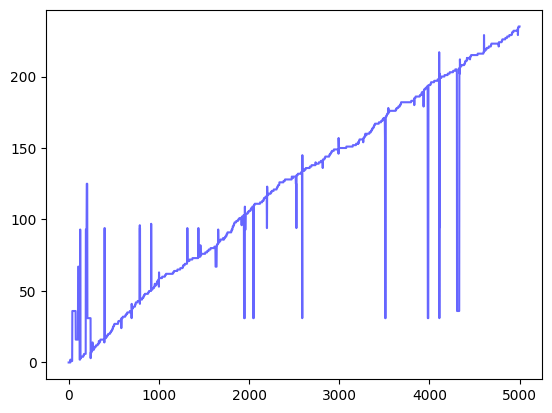

In [52]:
my_labels=relabel(my_labels)
plt.plot(my_labels, label='My label', alpha=0.6, color='blue')
plt.show()

In [53]:

def create_auto_assignment(intensity_evolution, intensity_threshold):
    # Pattern change is induced when intensity exceeds threshold
    pattern_change = intensity_evolution > intensity_threshold
    pattern_change = np.where(pattern_change)[0]
    pattern_change = np.hstack(([0], pattern_change, [len(intensity_evolution)]))

    reference_assignment = np.nan * np.ones(intensity_evolution.shape[0])
    for idx in range(len(pattern_change) - 1):
        frame_start = pattern_change[idx]
        frame_end = pattern_change[idx + 1]
        reference_assignment[frame_start:frame_end] = idx

    return reference_assignment, pattern_change

def benchmark_assignment(test_assignment, reference_assignment):
    test_assignment = np.squeeze(test_assignment)
    reference_assignment = np.squeeze(reference_assignment)

    # Which clusters do we have?
    clusters_test = np.unique(test_assignment[~np.isnan(test_assignment)])
    clusters_ref = np.unique(reference_assignment[~np.isnan(reference_assignment)])

    sz = np.max(
        [
            len(clusters_test),
            len(clusters_ref),
        ]
    )

    # Split test clusters
    test_cluster_matrix = np.zeros(
        (sz, sz, len(test_assignment)),
        dtype=bool,
    )
    for i in range(len(clusters_test)):
        tmp = test_assignment == i
        test_cluster_matrix[i, :] = tmp[np.newaxis, :]

    # Split reference clusters
    clusters_ref = np.unique(reference_assignment[~np.isnan(reference_assignment)])

    ref_cluster_matrix = np.zeros((sz, len(reference_assignment)))
    for i in range(len(clusters_ref)):
        tmp = reference_assignment == i
        ref_cluster_matrix[i, :] = tmp[np.newaxis, :]

    # Compare test and reference clusters
    comparison = test_cluster_matrix * ref_cluster_matrix[np.newaxis, ...]

    # What is the percentage of overlap of each cluster?
    spread = np.sum(comparison, axis=-1)
    nr_frames = np.sum(test_cluster_matrix, axis=-1)
    spread_percentage = spread / nr_frames
    spread_percentage[np.isinf(spread_percentage)] = 0

    # What is the error_rate?
    error = 1 - np.max(spread_percentage, axis=-1)
    error_rate = error * (nr_frames[:, 0] / np.sum(nr_frames[:, 0]))
    total_error = np.nansum(error_rate)

    # To-do: Put into pandas dataframe

    # Create some nice plots
    fig, ax = plt.subplots(2, 2, figsize=(10, 8))


    mi, ma = np.nanpercentile(spread[spread != 0], [5, 95])
    m00 = ax[0, 0].imshow(np.transpose(spread), vmin=mi, vmax=ma)
    ax[0, 0].set_ylabel("Reference assignment cluster (expanded)")
    ax[0, 0].set_xlabel("Test assignment cluster (expanded)")
    ax[0, 0].set_ylim([0, len(clusters_ref)])
    # cb00 = plt.colorbar(m00, label="Distribution in reference clusters")

    mi, ma = np.nanpercentile(spread_percentage[spread_percentage != 0], [1, 99])
    m01 = ax[0, 1].imshow(np.transpose(spread_percentage), vmin=mi, vmax=ma)
    ax[0, 1].set_ylabel("Reference assignment cluster (expanded)")
    ax[0, 1].set_xlabel("Test assignment cluster (expanded)")
    ax[0, 1].set_ylim([0, len(clusters_ref)])
    # cb01 = plt.colorbar(m01, label="Distribution in reference clusters in %")

    ax[1, 0].plot(error)
    ax[1, 0].grid()
    ax[1, 0].set_xlabel("Test cluster")
    ax[1, 0].set_ylabel("Relative error of each cluster")

    ax[1, 1].plot(100 * error_rate)
    ax[1, 1].grid()
    ax[1, 1].set_xlabel("Test cluster")
    ax[1, 1].set_ylabel("Cluster Error weighted with total number of frames in %")

    print("Your total assignment error: %.2f %%" % (100 * total_error))

    return 100 * total_error

You are dropping: []
number of drop 0
235


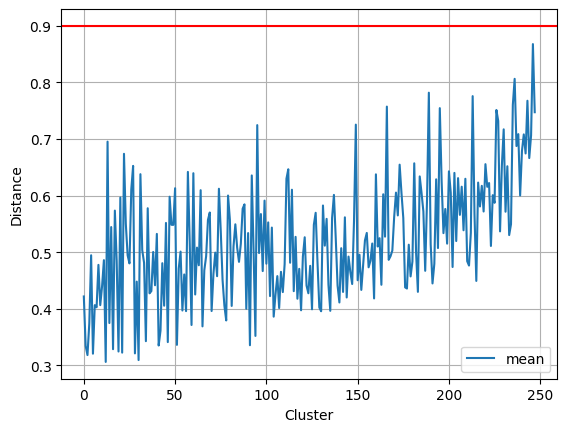

In [54]:
# Not needed

dist_metric_type = "braycurtis"
apply_dist = 1
cutoff = 0.9
filter_nr_frames=0

# Loop over all clusters to see some kind of trend for certain monitoring parameters
mean_d = np.nan * np.ones(len(cluster))

for cluster_idx in range(len(cluster)):
    # Reconstruct correlation map
    tmp_corr=SPC.reconstruct_correlation_map(
                cluster[cluster_idx]['Cluster_Frames'],
                cluster[cluster_idx]['Cluster_Frames'],
                fragment,
                0,
                metric)

    # Distance specific parameter
    # Calculate higher orders of distance metrics
    dist_metric = tmp_corr.copy()
    if apply_dist > 0:
        for n in range(1, apply_dist + 1):
            dist_metric = pairwise_distances(
                dist_metric, metric=dist_metric_type, n_jobs=-1
            )

    # Calc monitoring parameter
    if len(cluster[cluster_idx]['Cluster_Frames']) > filter_nr_frames:
        mean_d[cluster_idx] = np.mean(dist_metric[dist_metric != 1])
    else:
        mean_d[cluster_idx] = 1


fig, ax = plt.subplots()
ax.plot(mean_d, label="mean")
ax.axhline(y=cutoff, xmin=0, xmax=cluster_idx, color="r")
ax.set_xlabel("Cluster")
ax.set_ylabel("Distance")
ax.grid()
ax.legend()

# Filter all irrelevant clusters
cluster_indices = np.arange(len(cluster))[mean_d > cutoff]
print("You are dropping: %s" % cluster_indices)

my_labels_filter=my_labels.copy()
for i in cluster_indices:
    my_labels_filter=[np.nan if item==i else item for item in my_labels_filter]
print("number of drop",np.sum(np.isnan(my_labels_filter)))
print(np.count_nonzero(np.unique(my_labels_filter)))

my_labels_filter=relabel(my_labels_filter)


# Analyse Result

In [61]:
reference_assignment, _ = create_auto_assignment(
    intensity[idx],2.4e6)

C:\Users\sunhw\AppData\Local\Temp\ipykernel_12956\3149350230.py:53: RuntimeWarning: invalid value encountered in divide
  spread_percentage = spread / nr_frames


Your total assignment error: 14.72 %
Your total assignment error: 21.67 %


np.float64(21.67300380228137)

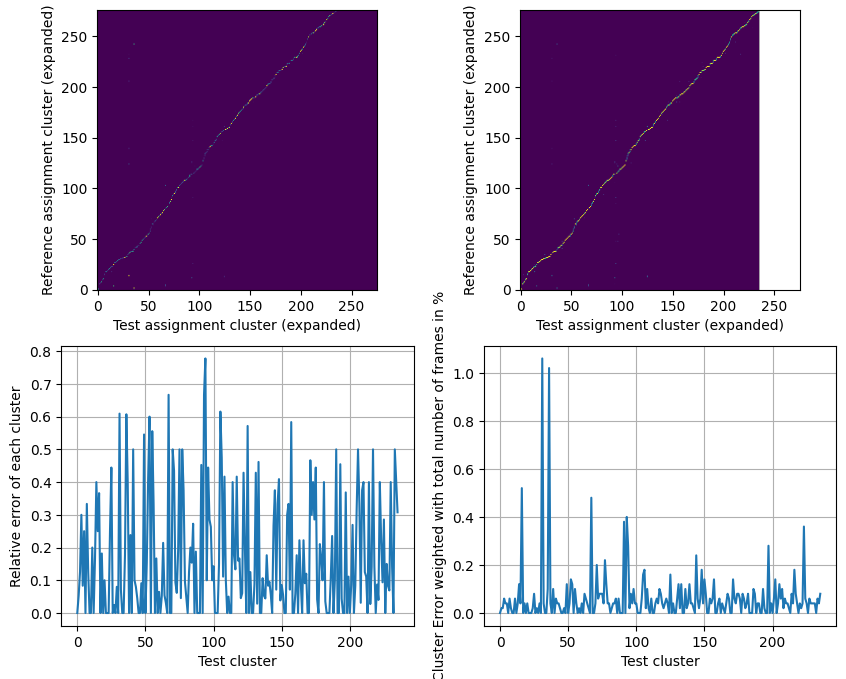

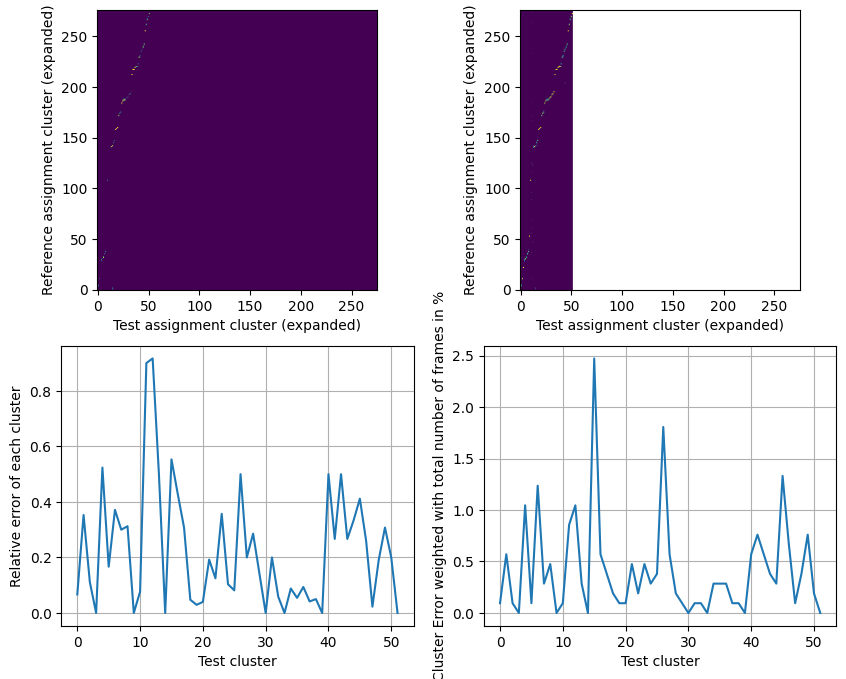

In [62]:
#My label
benchmark_assignment(my_labels,reference_assignment)
#CK label
benchmark_assignment(relabel(assignment[idx]),reference_assignment)

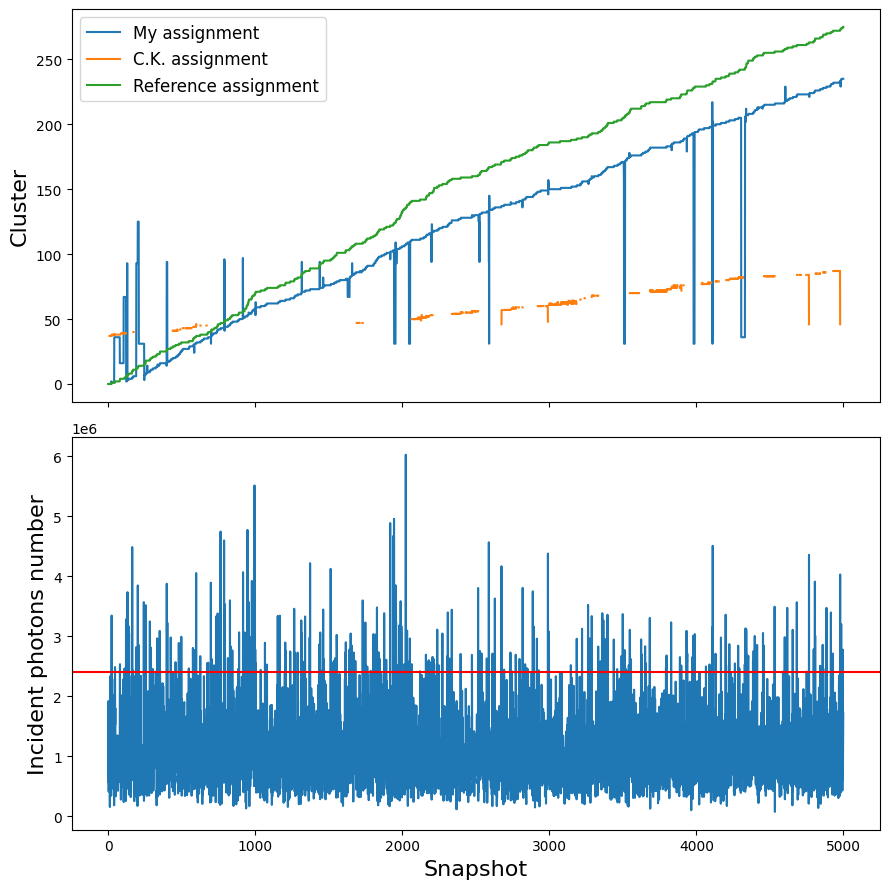

In [63]:
#corr_map = fragment[v_index,:][:,v_index]
show_idx=np.arange(0,5000)

fig, ax = plt.subplots(2,1,sharex=True,figsize=(9,9))
#mi, ma = np.percentile(corr_map[corr_map!=1],[1,99])                       
#ax[0].imshow(corr_map,vmin=mi,vmax=ma)
ax[0].plot(my_labels[show_idx],label = "My assignment")
ax[0].plot(np.array(assignment[idx])[show_idx],label = "C.K. assignment")
ax[0].plot(reference_assignment[show_idx],label = "Reference assignment")
ax[0].set_ylabel('Cluster', fontsize=16)
ax[0].legend(fontsize=12)

ax[1].plot(intensity[idx][show_idx])
ax[1].axhline(2.4e6,xmin=0,xmax=len(idx),color="r")
ax[1].set_ylabel('Incident photons number', fontsize=16)
ax[1].set_xlabel('Snapshot', fontsize=16)
#plt.subplots_adjust(hspace=0.03)
plt.tight_layout()

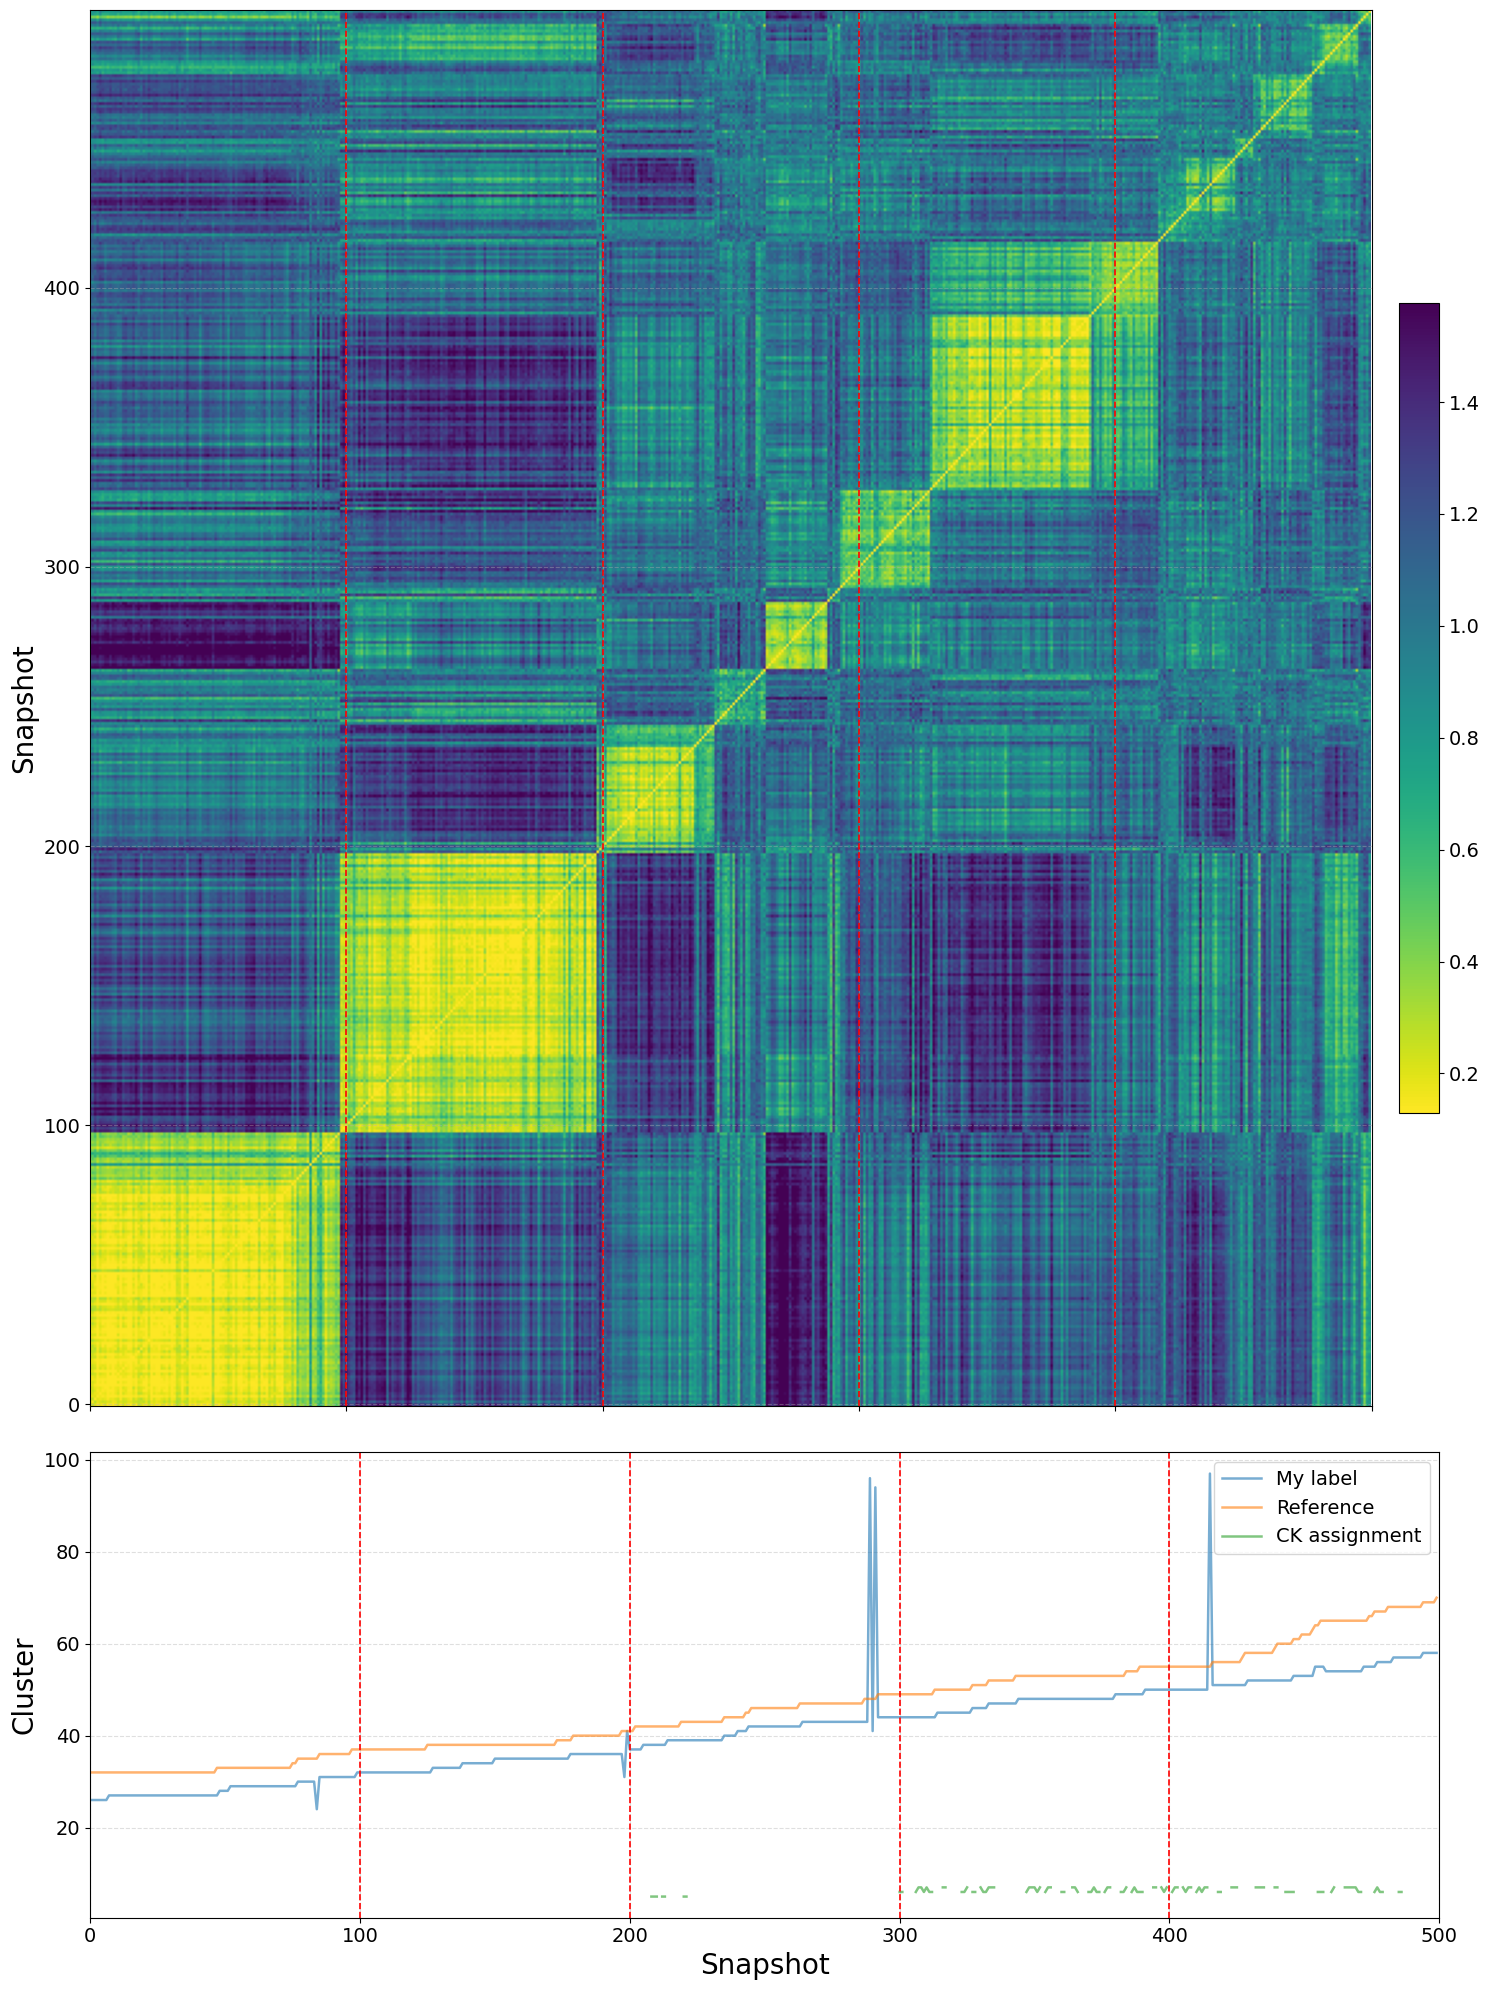

In [64]:
# --------------------------------------------
# Visualization of correlation map + labels
# --------------------------------------------

# Select frames to visualize
show_idx = np.arange(500, 1000)
n_show = len(show_idx)

# Vertical reference lines (divide region into 5 equal segments)
compare_xs = (np.linspace(0, n_show, 6)[1:-1]).astype(int)

# Reconstruct second-order correlation map
show_fragment = SPC.reconstruct_correlation_map(
    show_idx,
    show_idx,
    fragment,
    order=2,
    metric="correlation"
)

# Robust color scaling (ignore near-zero noise floor)
valid_vals = show_fragment[show_fragment >= 1e-5]
vmin, vmax = np.percentile(valid_vals, [1, 99])

# --------------------------------------------
# Figure layout
# --------------------------------------------
fig = plt.figure(figsize=(15, 20))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0)

# --------------------------------------------
# Top: Correlation heatmap
# --------------------------------------------
im = ax0.imshow(
    show_fragment,
    vmin=vmin,
    vmax=vmax,
    cmap="viridis_r",
    aspect="auto"
)

ax0.invert_yaxis()
ax0.set_xlim(0, n_show)
ax0.set_ylabel("Snapshot", fontsize=20)
#ax0.set_title("Second-order correlation map of Frames 23,000–25,000", fontsize=22)
ax0.tick_params(labelbottom=False)

# Add colorbar aligned to heatmap
cbar = fig.colorbar(im, ax=ax0, fraction=0.03, pad=0.02)
cbar.ax.tick_params(labelsize=14)

# --------------------------------------------
# Bottom: Label comparison
# --------------------------------------------
x_axis = np.arange(n_show)

ax1.plot(x_axis, my_labels[show_idx], label="My label", alpha=0.6, lw=1.8)
ax1.plot(x_axis, reference_assignment[show_idx], label="Reference", alpha=0.6, lw=1.8)
ax1.plot(x_axis, assignment[show_idx], label="CK assignment", alpha=0.6, lw=1.8)

ax1.set_ylabel("Cluster", fontsize=20)
ax1.set_xlabel("Snapshot", fontsize=20)
ax1.legend(fontsize=14)
#ax1.set_title("Clustering result of 23,000–25,000", fontsize=22)

# --------------------------------------------
# Grid + vertical reference lines
# --------------------------------------------
for ax in [ax0, ax1]:
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.tick_params(axis="both", labelsize=14)
    for x in compare_xs:
        ax.axvline(x=x, color="red", linestyle="--", linewidth=1.2)

# --------------------------------------------
# Final layout
# --------------------------------------------
plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.show()
